In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

import time
import random


In [28]:
## Set seed

def set_seed():

    SEED_VALUE = 123

    random.seed(SEED_VALUE) # python's built in random module
    np.random.seed(SEED_VALUE) # numpy's random module
    torch.manual_seed(SEED_VALUE) # pytorch' seed fix
     
    ## FOR GPU CUDA seed fixing

    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED_VALUE) # set seed for single GPU
        torch.cuda.manual_seed_all(SEED_VALUE) # set seed formulti-GPU

        torch.backends.cudnn.deterministic=True
        # torch.backends.cudnn.benchmark=True

set_seed()


In [35]:

set_seed()

floats = np.random.rand(5)    

print(floats)

[0.69646919 0.28613933 0.22685145 0.55131477 0.71946897]


In [51]:
transform = transforms.Compose([transforms.ToTensor()])

# Setup training data
train_dataset = datasets.CIFAR10(root='./data', # location to download data to
                               train=True,    # get training data
                               download=True, # download data if it doesn't exist on disk
                               transform=transform, # transformations on data
                            #    target_transform=None # you can transform labels as well
                            ) 
# Setup testing data
test_dataset  = datasets.CIFAR10(root='./data', 
                               train=False,   # get test data
                               download=True, 
                               transform=transform
                            )


Files already downloaded and verified
Files already downloaded and verified


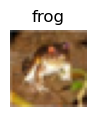

In [52]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

plt.figure(figsize=(2,1))
plt.imshow(image.permute(1,2,0))
# plt.title(f"Label: {label}")
plt.title(train_dataset.classes[label])
plt.axis("off")
plt.show()

In [53]:
all_pixels = []

for img, _ in train_dataset:
    pixels = img.view(-1)   # flatten image
    all_pixels.append(pixels)

all_pixels = torch.cat(all_pixels)

mean = all_pixels.mean().item()
std = all_pixels.std().item()

In [54]:
mean, std

(0.4733630120754242, 0.2515689432621002)

In [55]:
### transform the data >> zero mean , one std

In [56]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mean,), (std,))
    ])

# Setup training data
train_dataset = datasets.CIFAR10(root='./data', # location to download data to
                               train=True,    # get training data
                               download=True, # download data if it doesn't exist on disk
                               transform=transform, # transformations on data
                            #    target_transform=None # you can transform labels as well
                            ) 
# Setup testing data
test_dataset  = datasets.CIFAR10(root='./data', 
                               train=False,   # get test data
                               download=True, 
                               transform=transform
                            )


Files already downloaded and verified
Files already downloaded and verified


In [57]:
all_pixels = []

for img, _ in train_dataset:
    pixels = img.view(-1)   # flatten image
    all_pixels.append(pixels)

all_pixels = torch.cat(all_pixels)

mean = all_pixels.mean().item()
std = all_pixels.std().item()

print(mean, std)

-9.15527320621834e-10 0.9999999403953552


In [58]:
# How many samples are there? 
print("Train set:",len(train_dataset.data), len(train_dataset.targets))
print("Test Set:",len(test_dataset.data), len(test_dataset.targets))

Train set: 50000 50000
Test Set: 10000 10000


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8816433..2.09341].


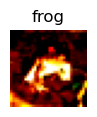

In [59]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

plt.figure(figsize=(2,1))
plt.imshow(image.permute(1,2,0))
# plt.title(f"Label: {label}")
plt.title(train_dataset.classes[label])
plt.axis("off")
plt.show()

In [60]:
from torch.utils.data import DataLoader

# Setup the batch size hyperparameter
BATCH_SIZE = 64


train_loader = DataLoader(train_dataset,         # dataset to turn into iterable
                          batch_size=BATCH_SIZE, # number of datapoints or samples per batch 
                          shuffle=True           # shuffle data every epoch
                        )

test_loader  = DataLoader(test_dataset, 
                          batch_size=BATCH_SIZE, 
                          shuffle=False          # don't necessarily have to shuffle the testing data
                        )

print(f"Dataloaders: {train_loader, test_loader}") 
print(f"Length of train dataloader: {len(train_loader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_loader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x13f0656c0>, <torch.utils.data.dataloader.DataLoader object at 0x13f064a60>)
Length of train dataloader: 782 batches of 64
Length of test dataloader: 157 batches of 64
